In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

from lite_org import LITE
from utils import load_data, preprocess_data
import os
from  utils import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
def calculate_redundancy(feature_map):
    num_samples, num_channels, ts_len = feature_map.shape
    activation_strength = torch.norm(feature_map, p=1, dim=-1)
    mean_activation = activation_strength.mean(dim=-1, keepdims=True)
    mask = (activation_strength > mean_activation)
    
    total_sum = 0
    for i in range(num_samples): # loop over each sample
        x = feature_map[i][mask[i]]
        x_norm = F.normalize(x, p=2, dim=1)
        cos_sim_matrix = x_norm @ x_norm.T
        cos_sim_value_features = cos_sim_matrix.sum() / 2
        total_sum += cos_sim_value_features.item()

    total_sum /= num_samples
    return total_sum


In [ ]:
dataset_names = [ 
                    'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
                    'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  'BME', 'Car', 'CBF', 'Chinatown',
                    'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
                    'CricketY', 'CricketZ', 
                    'DiatomSizeReduction',
                    'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
                    'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
                    'ECG5000', 'ECGFiveDays',  'EOGHorizontalSignal', 'EthanolLevel', 
                    'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
                    'FiftyWords', 'Fish', 'FreezerRegularTrain',
                    'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
                    'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
                    'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
                    'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
                    'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
                    'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
                    'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
                    'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
                    'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
                    'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
                    'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
                    'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
                    'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
                    'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
                    'Rock', 'ScreenType', 'SemgHandGenderCh2', 'SemgHandMovementCh2',
                    'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
                    'SmallKitchenAppliances', 'SmoothSubspace', 'SonyAIBORobotSurface1',
                    'SonyAIBORobotSurface2', 'StarLightCurves', 'Strawberry', 'SwedishLeaf',
                    'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 'Trace',
                    'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
                    'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
                    'UWaveGestureLibraryZ', 'Wafer',  'Worms', 'WormsTwoClass',     
                                    
                    'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
                    
                    ]

# dataset_names = ['BeetleFly']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    
    model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    # model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
     
    
    features_dict = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.forward_sparsity(input.float())
            features_dict[1].append(features[0][:, :96, :])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])

    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)
    

    # print(features_dict[1].shape)
    # print(features_dict[2].shape)
    # print(features_dict[3].shape)
    
    redundancy_amount_layer_1 = calculate_redundancy(features_dict[1])
    redundancy_amount_layer_2 = calculate_redundancy(features_dict[2])
    redundancy_amount_layer_3 = calculate_redundancy(features_dict[3])
    
    rows.append(redundancy_amount_layer_1)
    rows.append(redundancy_amount_layer_2)
    rows.append(redundancy_amount_layer_3)
    
    # print('Redundancy in the first layer: ', redundancy_amount_layer_1)
    # print('Redundancy in the second layer: ', redundancy_amount_layer_2)
    # print('Redundancy in the third layer: ', redundancy_amount_layer_3)
    
    
    # print('\n\n')
    # print('Redundancy amount for the sparse base model')
    model_base_sparse = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    model_base.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-6_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
    
    
    features_dict = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.forward_sparsity(input.float())
            features_dict[1].append(features[0][:, :96, :])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])

    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)
    

    # print(features_dict[1].shape)
    # print(features_dict[2].shape)
    # print(features_dict[3].shape)
    
    redundancy_amount_layer_1 = calculate_redundancy(features_dict[1])
    redundancy_amount_layer_2 = calculate_redundancy(features_dict[2])
    redundancy_amount_layer_3 = calculate_redundancy(features_dict[3])
    
    rows.append(redundancy_amount_layer_1)
    rows.append(redundancy_amount_layer_2)
    rows.append(redundancy_amount_layer_3)

    
    # print('Redundancy in the first layer: ', redundancy_amount_layer_1)
    # print('Redundancy in the second layer: ', redundancy_amount_layer_2)
    # print('Redundancy in the third layer: ', redundancy_amount_layer_3)
    
    redundancy_df = pd.concat([redundancy_df, pd.DataFrame([rows], columns=columns)])

In [4]:
redundancy_df.shape

(128, 7)

p_value:  1.4446835385664304e-19


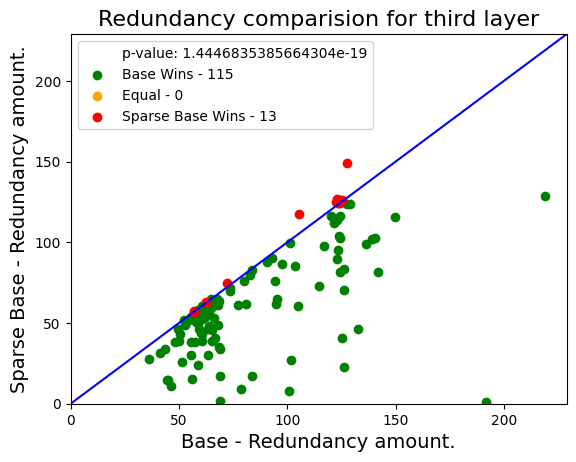

In [13]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(redundancy_df['base_red_3'].tolist(), redundancy_df['sparse_red_3'])
print('p_value: ', p_value)

plot_1v1_perf(redundancy_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=redundancy_df['base_red_3'].max()+10, 
              co_col='sparse_red_3', 
              base_col='base_red_3', 
              xlabel='Base - Redundancy amount.', 
              ylabel='Sparse Base - Redundancy amount.', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Redundancy comparision for third layer', 
              file_name='redundancy_sparse_layer_3_1e-6')

p_value:  1.0008903964883158e-21


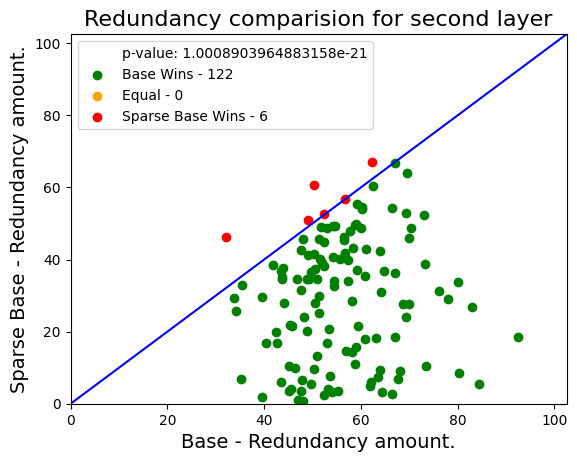

In [14]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(redundancy_df['base_red_2'].tolist(), redundancy_df['sparse_red_2'])
print('p_value: ', p_value)

plot_1v1_perf(redundancy_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=redundancy_df['base_red_2'].max()+10, 
              co_col='sparse_red_2', 
              base_col='base_red_2', 
              xlabel='Base - Redundancy amount.', 
              ylabel='Sparse Base - Redundancy amount.', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Redundancy comparision for second layer', 
              file_name='redundancy_sparse_layer_2_1e-6')

p_value:  1.5566659404202833e-20


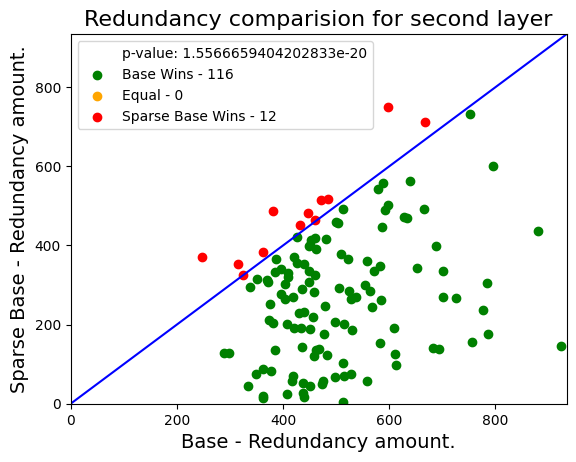

In [15]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(redundancy_df['base_red_1'].tolist(), redundancy_df['sparse_red_1'])
print('p_value: ', p_value)

plot_1v1_perf(redundancy_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=redundancy_df['base_red_1'].max()+10, 
              co_col='sparse_red_1', 
              base_col='base_red_1', 
              xlabel='Base - Redundancy amount.', 
              ylabel='Sparse Base - Redundancy amount.', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Redundancy comparision for second layer', 
              file_name='redundancy_sparse_layer_1_1e-6')

feat map shape:  torch.Size([32, 512])


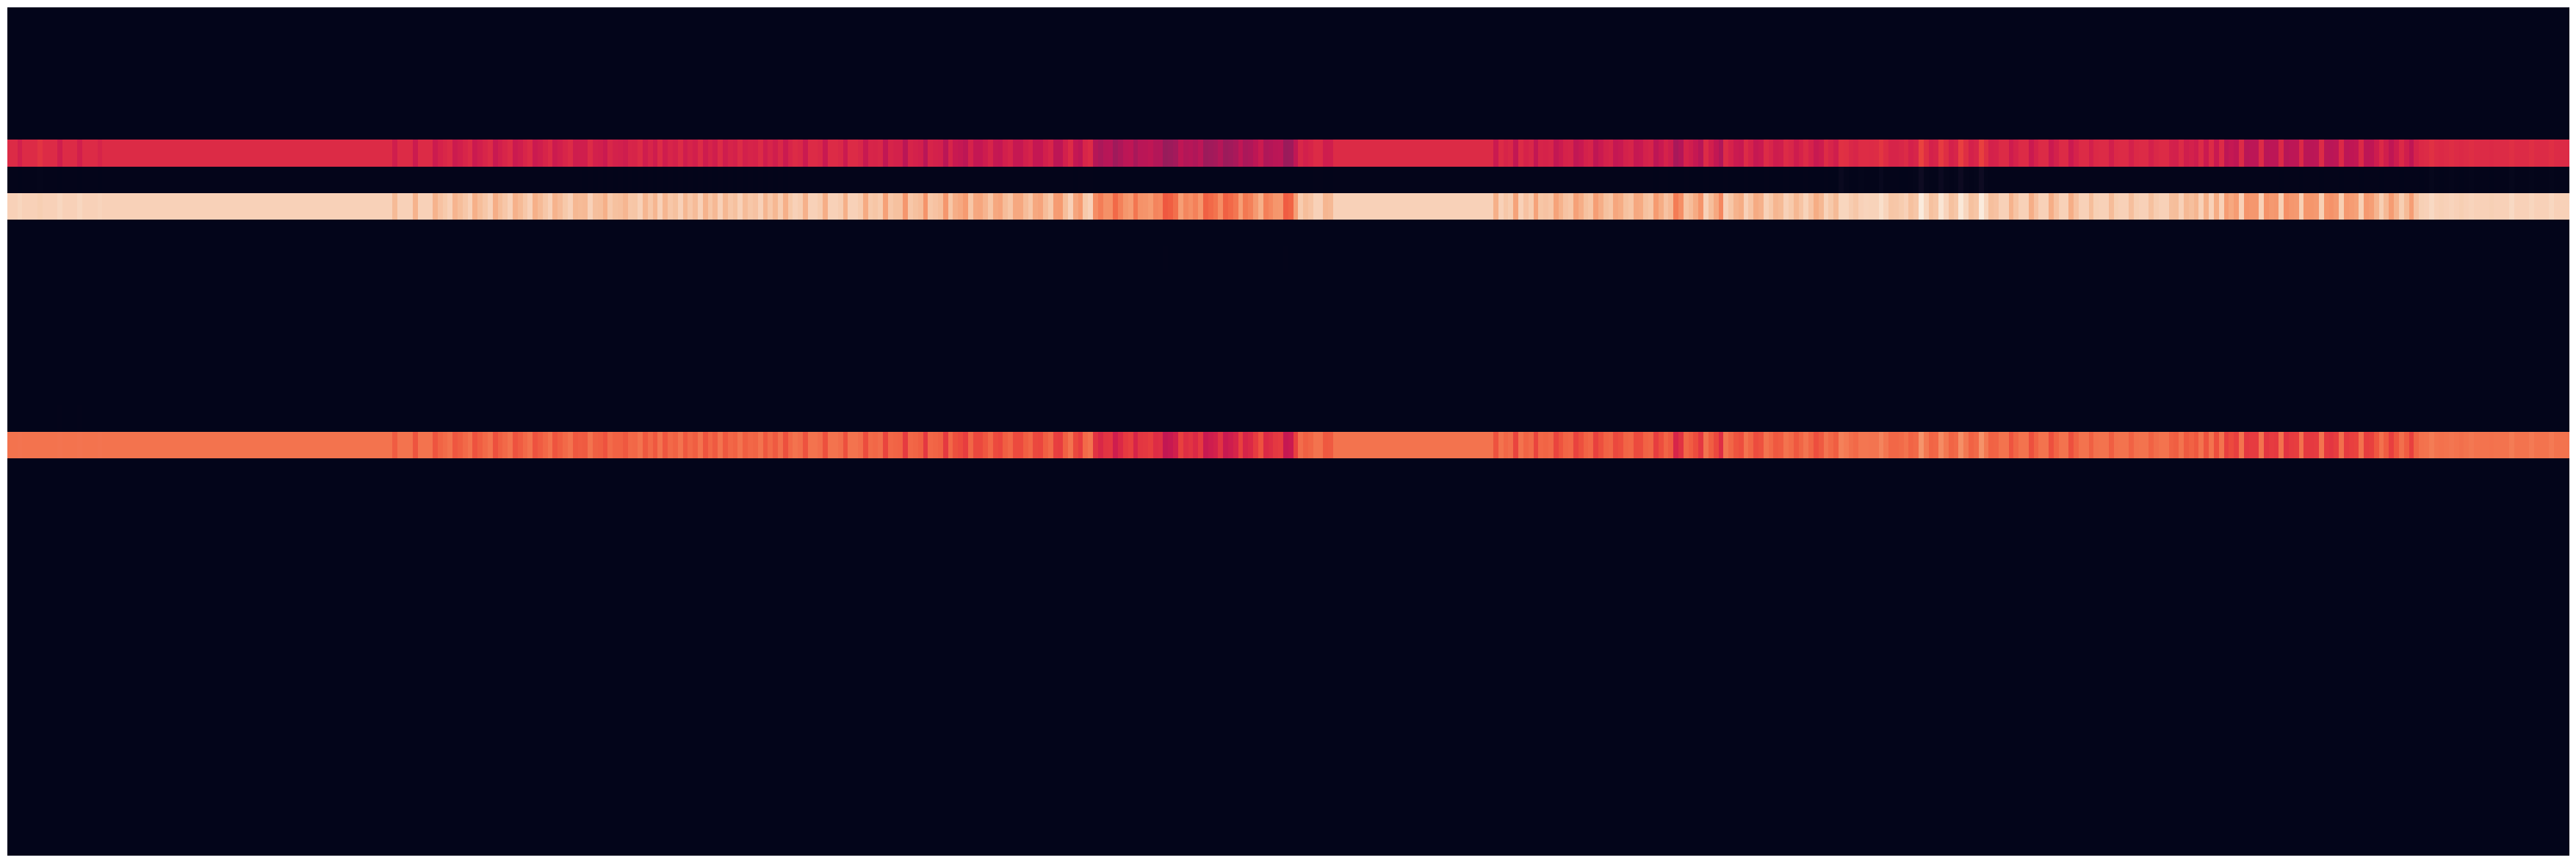

In [145]:
feat_map = features_dict[3][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=False )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf', bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()


In [14]:
dataset_names = ['ACSF1']
columns=['Dataset', 'base_red_1', 'base_red_2', 'base_red_3',  'sparse_red_1', 'sparse_red_2', 'sparse_red_3',]
redundancy_df = pd.DataFrame(columns=columns)
seed = 9409

for dataset in dataset_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, mini_batch_size=64)
    testloader = preprocess_data(xtest, ytest, mini_batch_size=64)
    
    length_TS = int(xtrain.shape[1])
    n_classes = len(np.unique(ytrain))
    
    model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
    # model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
    model_base.load_state_dict(torch.load(os.getcwd() + f'/results/magnitude/mag_seed_{seed}/{dataset}/best_model.pt'))
    
    model_base.cuda()
    model_base.eval()
    
    features_dict = {1: [], 2: [], 3: []}

    with torch.no_grad():
        for b_idx, (input, target) in enumerate(trainloader):
            input, target = input.cuda(), target.cuda()
            output, features = model_base.forward_sparsity(input.float())
            features_dict[1].append(features[0][:, :96, :])
            features_dict[2].append(features[1])
            features_dict[3].append(features[2])

    features_dict[1] = torch.cat(features_dict[1], dim=0)
    features_dict[2] = torch.cat(features_dict[2], dim=0)
    features_dict[3] = torch.cat(features_dict[3], dim=0)

feat map shape:  torch.Size([32, 1460])


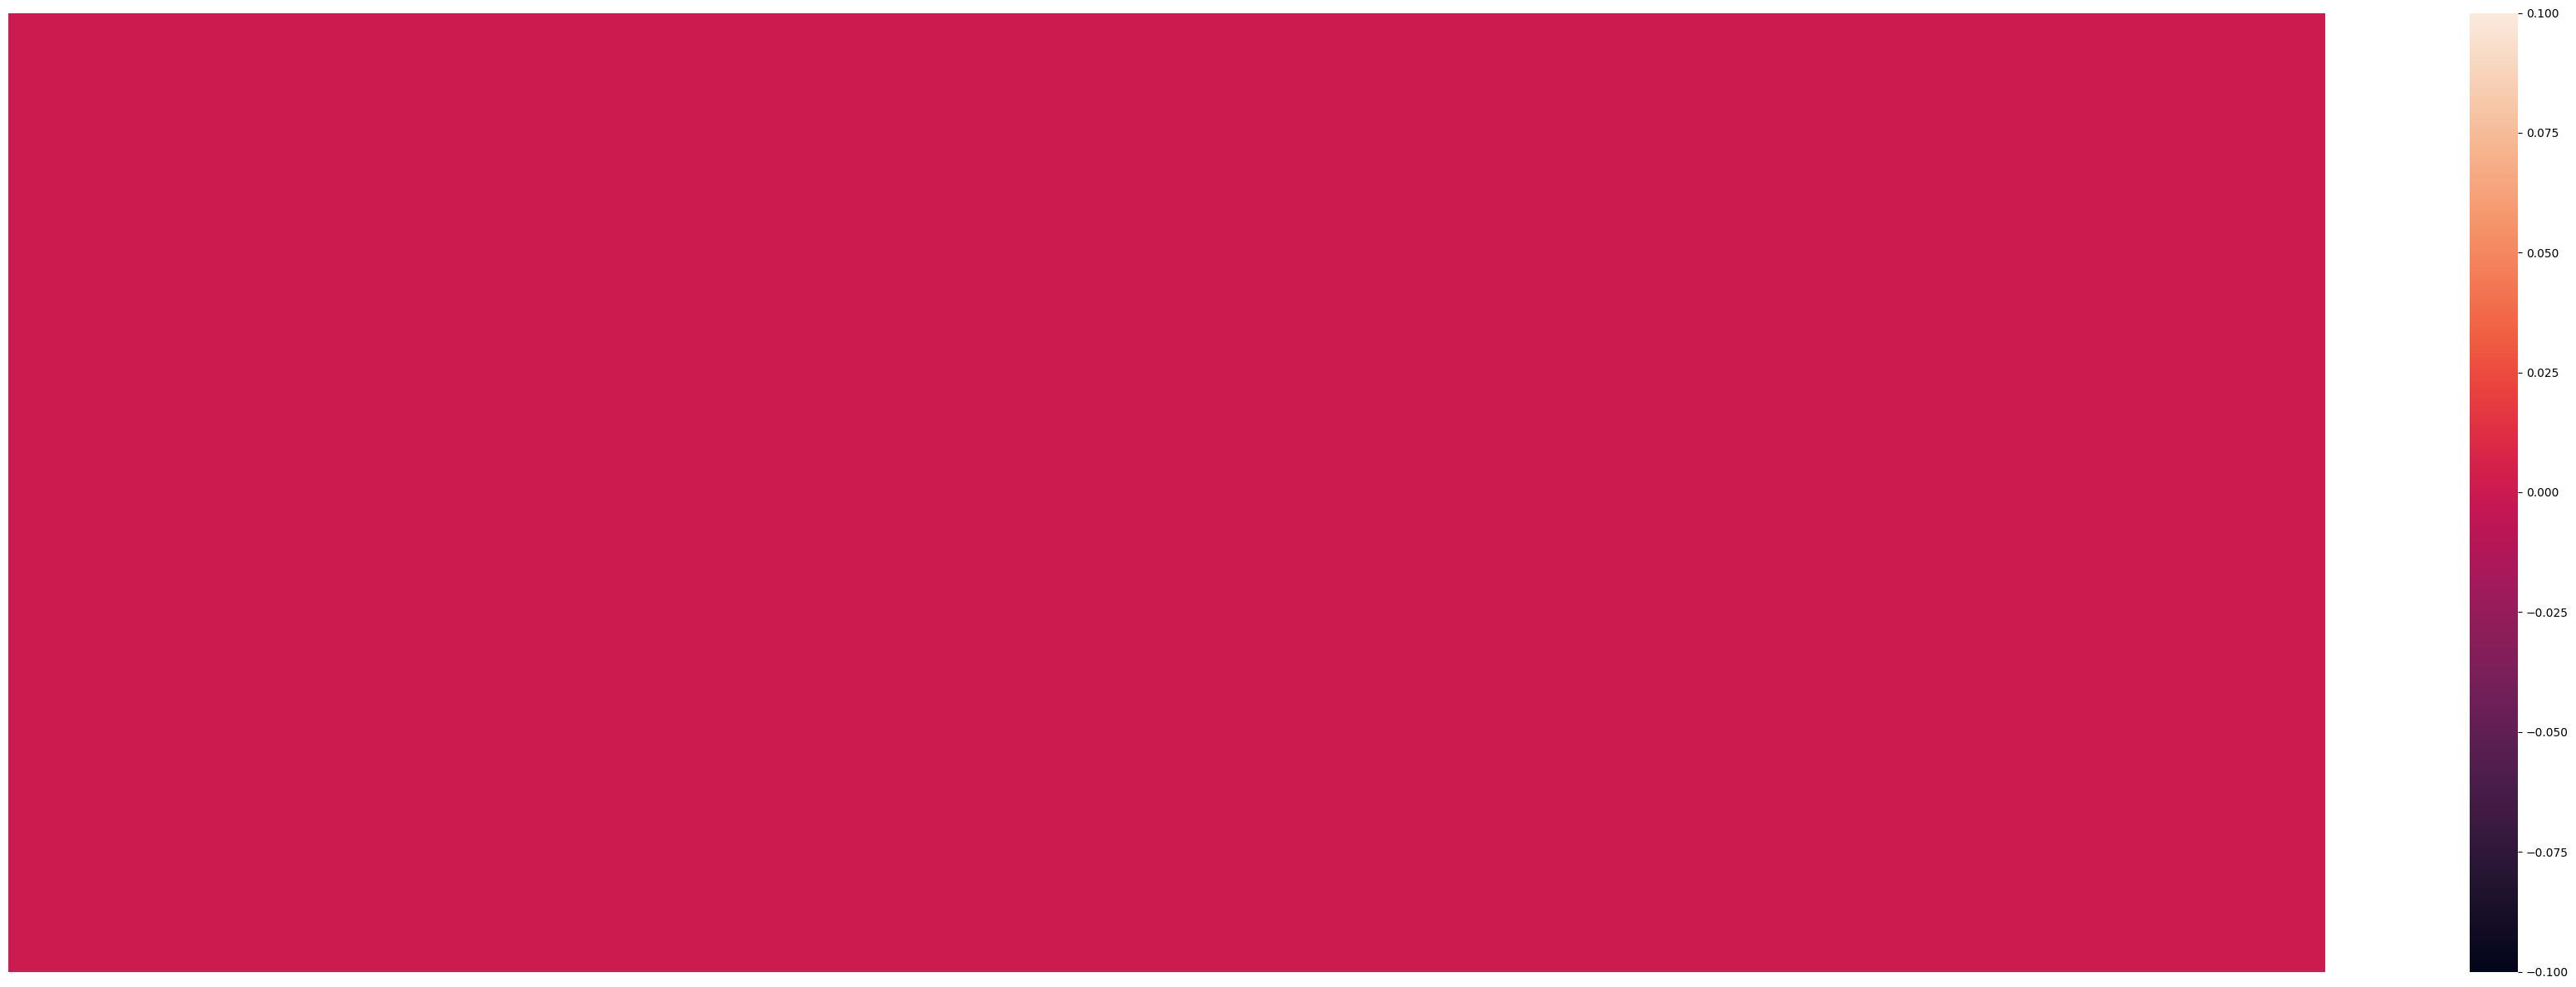

In [17]:
feat_map = features_dict[3][0].detach().cpu()
# feat_map = tmp.detach().cpu()

print('feat map shape: ', feat_map.shape)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(45, 15))
sns.heatmap(feat_map, annot=False, cbar=True )
plt.xticks([])  
plt.yticks([])  
plt.savefig('tmp.pdf')
plt.show()
plt.close()

In [3]:
def evaluate_ensemble_base(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            # Apply softmax to convert logits to probabilities
   
            avg_probs = sum(probs) / len(probs)

            # Get the predicted class
            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    print('')
    accuracy = accuracy_score(all_targets, all_preds)
    print(f'Ensemble Accuracy: {accuracy:.4f}')
    return accuracy

def evaluate_ensemble_pruned(models, dataloader):
    models = [model.eval() for model in models]
    models = [model.cuda() for model in models]
    
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.cuda(), target.cuda()

            outputs = [model.forward_sparsity(data.float())[0] for model in models]
            probs = [F.softmax(output, dim=1) for output in outputs]
            # Apply softmax to convert logits to probabilities
   
            avg_probs = sum(probs) / len(probs)

            # Get the predicted class
            preds = avg_probs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_targets, all_preds)
    print(f'Ensemble Accuracy: {accuracy:.4f}')
    return accuracy

In [4]:
def copy_params(base_model, pruned_model, conv_group_1, conv_group_2, conv_group_3, all_indicies, indicies_2, indicies_3,  out_dir):
    print('conv_group_1 size: ', conv_group_1.shape)
    print('conv_group_2 size: ', conv_group_2.shape)
    print('conv_group_3 size: ', conv_group_3.shape)
    
    model_base_state_dict = base_model.state_dict()
    model_pruned_state_dict = pruned_model.state_dict()

    for name, param in model_base_state_dict.items():
        print()
        if 'num_batches_tracked' in name:
            continue
        
        elif 'inception.inception_layers.0.weight' in name:            
            model_pruned_state_dict[name] = param[conv_group_1].clone()
            print(' 111 **************************************\n\n')
            
        elif 'inception.inception_layers.1.weight' in name:            
            model_pruned_state_dict[name] = param[conv_group_2].clone()
            print(' 222 **************************************\n\n')
            
        elif 'inception.inception_layers.2.weight' in name:
            model_pruned_state_dict[name] = param[conv_group_3].clone()
            print(' 333 **************************************\n\n')

        elif 'inception.hybrid.hybrid_block' in name:
            model_pruned_state_dict[name] = param.clone()
            print(' 444 **************************************\n\n')

        elif 'inception.bn' in name:
            model_pruned_state_dict[name] = param[all_indicies].clone()
            print(' 555 **************************************')
            
        elif 'fcn_module1.depthwise_conv' in name:
            model_pruned_state_dict[name] = param[all_indicies].clone()
            print(' 666 **************************************')

        elif 'fcn_module1.pointwise_conv' in name:
            rows, cols = torch.meshgrid(indicies_2, all_indicies, indexing="ij")
            model_pruned_state_dict[name] = param[rows, cols, :].clone()
            print(' 777 **************************************')
            
        elif 'fcn_module1.bn' in name:
            model_pruned_state_dict[name] = param[indicies_2].clone()
            print(' 888 **************************************')
            
        elif 'fcn_module2.depthwise_conv' in name:
            model_pruned_state_dict[name] = param[indicies_2].clone()
            print(' 999 **************************************')

        elif 'fcn_module2.pointwise_conv' in name:
            rows, cols = torch.meshgrid(indicies_3, indicies_2, indexing="ij")
            model_pruned_state_dict[name] = param[rows, cols, :].clone()
            print(' 10_10 **************************************')

        elif 'fcn_module2.bn' in name:
            model_pruned_state_dict[name] = param[indicies_3].clone()
            print(' 11_11 **************************************')

        elif 'fc1.weight' in name:
            model_pruned_state_dict[name] = param[:, indicies_3].clone()
            print(' 12_12 **************************************')

        elif 'fc1.bias' in name:
            model_pruned_state_dict[name] = param.clone()
            print(' 13_13 **************************************')
        
        else:
            print('AAAAAAAAAAAAAAAAAAAAA')
        #     print('Yes')
    
    print('\n\n')
    pruned_model.load_state_dict(model_pruned_state_dict)    
    torch.save(pruned_model, out_dir + 'pruned_model.pth')
    return pruned_model

In [5]:
def test(model, dataloader):
    
    model.eval()
    correct, total = 0, 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        
        inputs, targets = inputs.cuda(), targets.cuda()

        outputs, features = model.forward_sparsity(inputs.float())
        
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += predicted.eq(targets.data).cpu().sum().float().item()

    # print('Accuracy: ', 100. * correct / total)
    return 100. * correct / total

In [ ]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]

# ds_names = ['ACSF1']
seeds = [9409, 3804, 3952, 2561, 5296]
# seeds = [2561]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens', 'base_params', 'co_params']
res_df_2 = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    print('Dataset: ', dataset)
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))
    models_base, models_base_norm, models_pruned = [], [], []
    num_params_pruned, num_params_base = 0, 0
    
    for seed in seeds:
        print('seed: ', seed)
        # model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        # model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        # model_base_norm.cuda()
        # model_base_norm.eval()
        # models_base.append(model_base)
        # rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        # num_params_base += sum(p.numel() for p in model_base.parameters())
        
        model_base_norm = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base_norm.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_base_norm.cuda()
        model_base_norm.eval()
        models_base_norm.append(model_base_norm)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_base_norm.parameters())
        
        all_mask_1, all_mask_2, all_mask_3 = [], [], []
        with torch.no_grad():
            for b_idx, (data, target) in enumerate(trainloader):
                data, target = data.cuda(), target.cuda()
                outputs, features, prune_ratios, masks, depth_outs  = model_base_norm.forward_sparsity_2(data.float())
                all_mask_1.append(masks[0])
                all_mask_2.append(masks[1])
                all_mask_3.append(masks[2])
                
        all_mask_1 = torch.cat(all_mask_1, dim=0)
        all_mask_2 = torch.cat(all_mask_2, dim=0)
        all_mask_3 = torch.cat(all_mask_3, dim=0)
        print('all_mask_1 shape: ', all_mask_1.shape)
        
        mask_1_org = all_mask_1.squeeze(-1)
        mask_1 = mask_1_org[:, :96]
        mask_2 = all_mask_2.squeeze(-1)
        mask_3 = all_mask_3.squeeze(-1)

        # Third layer
        tmp_3 = mask_3.sum(dim=0) # (num of filters)
        indicies_3, conv_3_size  = torch.where(tmp_3 > 1)[0], torch.where(tmp_3 > 1)[0].shape[0]
        if conv_3_size == 0:
            indicies_3 = torch.tensor([0], device=indicies_3.device)
            conv_3_size = 1
        
        # Second layer
        tmp_2 = mask_2.sum(dim=0)
        indicies_2, conv_2_size  = torch.where(tmp_2 > 1)[0], torch.where(tmp_2 > 1)[0].shape[0]
        if conv_2_size == 0:
            indicies_2 = torch.tensor([0], device=indicies_2.device)
            conv_2_size = 1

        # First layer
        tmp_1 = mask_1.sum(dim=0)
        indices = torch.where(tmp_1 > 1)[0]
        
        conv_group_1, conv_group_1_size = indices[indices < 32], indices[indices < 32].shape[0]
        conv_group_2, conv_group_2_size = indices[(indices >= 32) & (indices < 64)], indices[(indices >= 32) & (indices < 64)].shape[0]
        conv_group_3, conv_group_3_size = indices[(indices >= 64) & (indices < 96)], indices[(indices >= 64) & (indices < 96)].shape[0]
        # print('conv_group_1: ', conv_group_1)
            
        conv_group_2 = conv_group_2 - 32
        conv_group_3 = conv_group_3 - 64
        
        tmp = mask_1_org.sum(dim=0)
        print('mask_1_org shape: ', mask_1_org.shape)
        all_indicies = torch.where(tmp > 1)[0]
        all_indicies
        print('all indices after: ', all_indicies)
        
        if conv_group_1_size == 0:
            conv_group_1 = torch.tensor([0], device=indices.device)
            conv_group_1_size = 1
            all_indicies = torch.cat((all_indicies, torch.tensor([0], device=all_indicies.device)))
        if conv_group_2_size == 0:
            conv_group_2 = torch.tensor([0], device=indices.device)
            conv_group_2_size = 1            
            all_indicies = torch.cat((all_indicies, torch.tensor([32], device=all_indicies.device)))          
        if conv_group_3_size == 0:
            conv_group_3 = torch.tensor([0], device=indices.device)
            conv_group_3_size = 1
            print('all indices before: ', all_indicies)            
            all_indicies = torch.cat((all_indicies, torch.tensor([64], device=all_indicies.device)))
            print('all indices after: ', all_indicies)
        
            print('aaaa')
            

        print('conv_group_1 size: ', conv_group_1.shape)
        model_pruned = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, 
                    n_filters=[[conv_group_1_size, conv_group_2_size, conv_group_3_size], conv_2_size, conv_3_size])
        model_pruned.cuda()

        num_params_pruned += sum(p.numel() for p in model_pruned.parameters())
        print('Number of parameters from the pruned model: ', sum(p.numel() for p in model_pruned.parameters()) )
        
        out_dir = os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/'       
        print('Copying parameters started')         
        model_pruned = copy_params(model_base_norm, model_pruned, conv_group_1, conv_group_2, conv_group_3, all_indicies, indicies_2, indicies_3, out_dir )
        print('Copying parameters ended')         
        
        # model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_pruned.append(model_pruned)
        rows.append(test(model_pruned, testloader))
        print('\n\n')

        
            
    num_params_pruned /= 5
    num_params_base /= 5
    base_acc = evaluate_ensemble_base(models_base_norm, testloader)
    print('Base accuracy: ', base_acc)
    rows.append(base_acc)
    
    pruned_acc = evaluate_ensemble_base(models_pruned, testloader)
    print('Pruned model accuracy: ', pruned_acc)
    rows.append(pruned_acc)
    
    rows.append(num_params_base)
    rows.append(num_params_pruned)    
    
    res_df_2 = pd.concat([res_df_2, pd.DataFrame([rows], columns=columns)])    
    # break

Dataset:  ACSF1
seed:  9409
all_mask_1 shape:  torch.Size([100, 113, 1])
mask_1_org shape:  torch.Size([100, 113])
all indices after:  tensor([  0,   2,   4,   5,   6,   9,  11,  12,  13,  15,  16,  17,  20,  22,
         23,  24,  25,  27,  28,  30,  32,  34,  36,  37,  39,  41,  42,  44,
         45,  47,  49,  50,  51,  52,  56,  57,  58,  59,  60,  61,  62,  63,
         65,  66,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
         80,  82,  83,  84,  85,  86,  88,  89,  91,  92,  94,  96,  97,  98,
         99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112],
       device='cuda:0')
conv_group_1 size:  torch.Size([20])
Number of parameters from the pruned model:  7594
Copying parameters started
conv_group_1 size:  torch.Size([20])
conv_group_2 size:  torch.Size([22])
conv_group_3 size:  torch.Size([25])

 111 **************************************



 222 **************************************



 333 **************************************



 444 

In [7]:
res_df_2

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens,base_params,co_params
0,ACSF1,89.000000,82.000000,91.000000,82.000000,89.000000,90.000000,92.000000,84.000000,91.000000,85.000000,0.920000,0.900000,10582.0,7089.4
0,Adiac,84.143223,67.263427,84.398977,78.516624,83.375959,72.634271,82.608696,49.360614,84.143223,71.611253,0.841432,0.785166,11473.0,8608.6
0,AllGestureWiimoteX,70.285714,68.571429,70.857143,70.428571,71.000000,70.571429,69.857143,70.285714,69.857143,68.571429,0.760000,0.762857,10582.0,8130.2
0,AllGestureWiimoteY,74.428571,72.714286,72.571429,71.571429,72.857143,71.714286,74.285714,74.285714,71.571429,72.000000,0.768571,0.780000,10582.0,7439.0
0,AllGestureWiimoteZ,66.142857,66.000000,67.714286,67.571429,66.571429,66.142857,68.000000,67.142857,65.857143,66.000000,0.750000,0.757143,10582.0,7308.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,70.791667,70.791667,70.595238,70.595238,70.571429,70.571429,71.184524,71.184524,70.095238,70.095238,0.753929,0.753929,11044.0,11044.0
0,ElectricDevices,66.398651,66.398651,66.437557,66.424588,66.891454,66.891454,66.191155,66.178187,68.175334,68.175334,0.690572,0.690572,10483.0,10092.2
0,FordA,93.712121,93.787879,94.469697,94.242424,93.333333,93.484848,93.939394,94.015152,94.090909,94.166667,0.953030,0.953030,10318.0,5803.2
0,FordB,77.654321,77.901235,80.246914,80.370370,74.938272,75.555556,78.641975,78.765432,77.901235,77.901235,0.790123,0.792593,10318.0,6128.4


In [8]:
res_df_2['prune_ratio'] = 1 - res_df_2['co_params'] / res_df_2['base_params']
res_df_2

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens,base_params,co_params,prune_ratio
0,ACSF1,89.000000,82.000000,91.000000,82.000000,89.000000,90.000000,92.000000,84.000000,91.000000,85.000000,0.920000,0.900000,10582.0,7089.4,0.330051
0,Adiac,84.143223,67.263427,84.398977,78.516624,83.375959,72.634271,82.608696,49.360614,84.143223,71.611253,0.841432,0.785166,11473.0,8608.6,0.249664
0,AllGestureWiimoteX,70.285714,68.571429,70.857143,70.428571,71.000000,70.571429,69.857143,70.285714,69.857143,68.571429,0.760000,0.762857,10582.0,8130.2,0.231695
0,AllGestureWiimoteY,74.428571,72.714286,72.571429,71.571429,72.857143,71.714286,74.285714,74.285714,71.571429,72.000000,0.768571,0.780000,10582.0,7439.0,0.297014
0,AllGestureWiimoteZ,66.142857,66.000000,67.714286,67.571429,66.571429,66.142857,68.000000,67.142857,65.857143,66.000000,0.750000,0.757143,10582.0,7308.0,0.309393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,70.791667,70.791667,70.595238,70.595238,70.571429,70.571429,71.184524,71.184524,70.095238,70.095238,0.753929,0.753929,11044.0,11044.0,0.000000
0,ElectricDevices,66.398651,66.398651,66.437557,66.424588,66.891454,66.891454,66.191155,66.178187,68.175334,68.175334,0.690572,0.690572,10483.0,10092.2,0.037279
0,FordA,93.712121,93.787879,94.469697,94.242424,93.333333,93.484848,93.939394,94.015152,94.090909,94.166667,0.953030,0.953030,10318.0,5803.2,0.437565
0,FordB,77.654321,77.901235,80.246914,80.370370,74.938272,75.555556,78.641975,78.765432,77.901235,77.901235,0.790123,0.792593,10318.0,6128.4,0.406048


In [9]:
res_df_2['prune_ratio'].mean()


np.float64(0.45952449528605654)

p_value:  3.770943952333033e-05


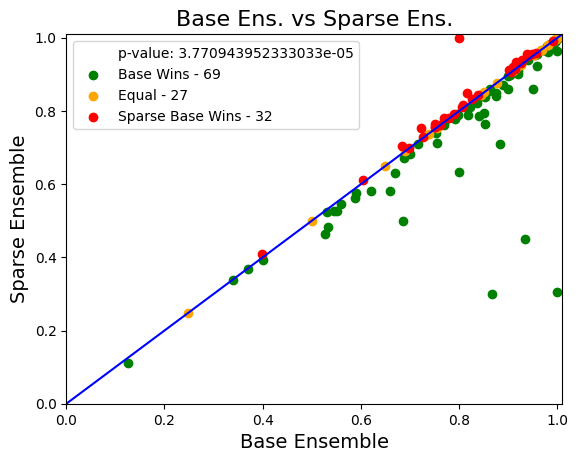

In [10]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Sparse Ensemble', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Base Ens. vs Sparse Ens.', 
              file_name=None)

p_value:  3.770943952333033e-05


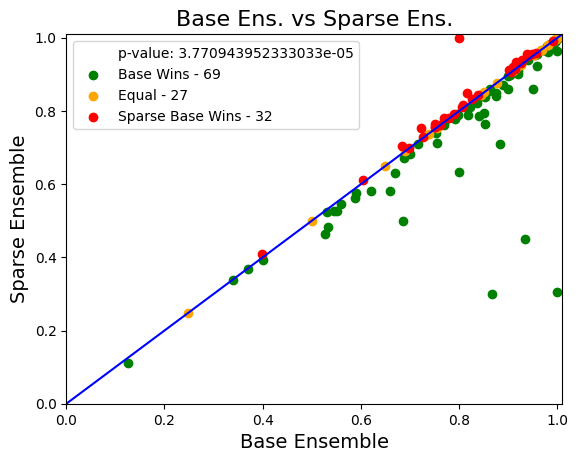

In [39]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Sparse Ensemble', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Base Ens. vs Sparse Ens.', 
              file_name=None)

In [49]:

seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens']
res_df = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))

    models_base, models_base_norm, models_pruned = [], [], []
    
    for seed in seeds:
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        print(sum(p.numel() for p in model_base.parameters()))
        
        # model_pruned = torch.load(os.getcwd() + f'/results/fine-tuned_rem/ins_sparse_seed_{seed}/{dataset}/best_model.pth')
        model_pruned = torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/pruned_model.pth',)
        models_pruned.append(model_pruned)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
    
    ens_acc_base = evaluate_ensemble_base(models_base, testloader)
    rows.append(ens_acc_base)

    ens_acc_base = evaluate_ensemble_base(models_pruned, testloader)
    rows.append(ens_acc_base)

    res_df = pd.concat([res_df, pd.DataFrame([rows], columns=columns)])


10582
10582
10582
10582
10582

Ensemble Accuracy: 0.9100

Ensemble Accuracy: 0.2500
11473
11473
11473
11473
11473

Ensemble Accuracy: 0.8517

Ensemble Accuracy: 0.7698
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7786

Ensemble Accuracy: 0.2086
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.8043

Ensemble Accuracy: 0.2957
10582
10582
10582
10582
10582

Ensemble Accuracy: 0.7600

Ensemble Accuracy: 0.2871
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.8057

Ensemble Accuracy: 0.7486
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.8500

Ensemble Accuracy: 0.8000
10318
10318
10318
10318
10318

Ensemble Accuracy: 0.9000

Ensemble Accuracy: 1.0000
10417
10417
10417
10417
10417

Ensemble Accuracy: 0.7000

Ensemble Accuracy: 0.3333
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9467

Ensemble Accuracy: 0.9133
10384
10384
10384
10384
10384

Ensemble Accuracy: 0.9500

Ensemble Accuracy: 0.6333
10351
10351
10351
10351
10351

Ensemble Accuracy: 0.9989

Ensemble Accuracy:

In [47]:
res_df

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens
0,ACSF1,91.000000,89.000000,90.000000,91.000000,87.000000,89.000000,87.000000,92.000000,90.000000,91.000000,0.910000,0.900000
0,Adiac,81.074169,84.143223,82.608696,84.398977,81.841432,83.375959,82.608696,82.608696,82.352941,84.143223,0.851662,0.785166
0,AllGestureWiimoteX,75.857143,70.285714,76.428571,70.857143,75.000000,71.000000,73.714286,69.857143,77.142857,69.857143,0.778571,0.762857
0,AllGestureWiimoteY,79.285714,74.428571,79.285714,72.571429,79.000000,72.857143,77.428571,74.285714,78.857143,71.571429,0.804286,0.780000
0,AllGestureWiimoteZ,75.857143,66.142857,72.571429,67.714286,72.571429,66.571429,73.714286,68.000000,69.142857,65.857143,0.760000,0.757143
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,Crop,71.744048,70.791667,71.708333,70.595238,71.363095,70.571429,71.595238,71.184524,71.797619,70.095238,0.757321,0.753929
0,ElectricDevices,67.098950,66.398651,67.578784,66.437557,68.071586,66.891454,67.928933,66.191155,68.214239,68.175334,0.700298,0.690572
0,FordA,95.075758,93.712121,95.606061,94.469697,95.530303,93.333333,95.000000,93.939394,94.924242,94.090909,0.955303,0.953030
0,FordB,82.222222,77.654321,83.086420,80.246914,82.098765,74.938272,83.950617,78.641975,82.839506,77.901235,0.840741,0.792593


p_value:  9.169633350896899e-12


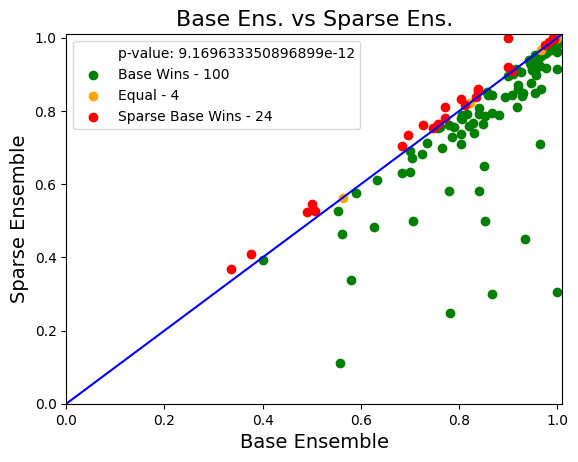

In [48]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Sparse Ensemble', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Base Ens. vs Sparse Ens.', 
              file_name=None)

p_value:  2.4706463382711518e-20


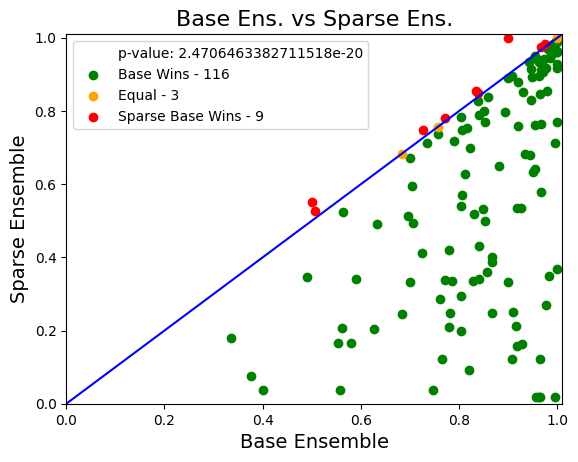

In [50]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df['base_ens'].tolist(), res_df['co_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='co_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Sparse Ensemble', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Base Ens. vs Sparse Ens.', 
              file_name=None)

## Old copy parameters

In [2]:

def test(model, dataloader):
    
    model.eval()
    correct, total = 0, 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        
        inputs, targets = inputs.cuda(), targets.cuda()

        outputs, features = model.forward_sparsity(inputs.float())
        
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += predicted.eq(targets.data).cpu().sum().float().item()

    # print('Accuracy: ', 100. * correct / total)
    return 100. * correct / total

In [7]:
ds_names = ['ACSF1',]

seeds = [9409, 3804, 3952, 2561, 5296]
# seeds = [2561]
columns = ['Dataset', 'base_1', 'co_1', 'base_2', 'co_2', 'base_3', 'co_3', 'base_4', 'co_4', 'base_5', 'co_5', 'base_ens', 'co_ens', 'base_params', 'co_params']
res_df_2 = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    print('Dataset: ', dataset)
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))
    models_base_norm, models_pruned = [], []
    num_params_pruned, num_params_base = 0, 0
    
    for seed in seeds:
        # model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        # model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        # models_base.append(model_base)
        # rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        # print(sum(p.numel() for p in model_base.parameters()))
        
        model_base_norm = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base_norm.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_base_norm.cuda()
        model_base_norm.eval()
        models_base_norm.append(model_base_norm)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_base_norm.parameters())
        
        
        all_mask_1, all_mask_2, all_mask_3 = [], [], []
        with torch.no_grad():
            for b_idx, (data, target) in enumerate(trainloader):
                data, target = data.cuda(), target.cuda()
                outputs, features, prune_ratios, masks, depth_outs  = model_base_norm.forward_sparsity_2(data.float())
                all_mask_1.append(masks[0])
                all_mask_2.append(masks[1])
                all_mask_3.append(masks[2])
                
        all_mask_1 = torch.cat(all_mask_1, dim=0)
        all_mask_2 = torch.cat(all_mask_2, dim=0)
        all_mask_3 = torch.cat(all_mask_3, dim=0)
        
        mask_1_org = all_mask_1.squeeze(-1)
        mask_1 = mask_1_org[:, :96]
        mask_2 = all_mask_2.squeeze(-1)
        mask_3 = all_mask_3.squeeze(-1)

        # Third layer
        tmp_3 = mask_3.sum(dim=0) # (num of filters)
        indicies_3, conv_3_size  = torch.where(tmp_3 > 1)[0], torch.where(tmp_3 > 1)[0].shape[0]
        
        # Second layer
        tmp_2 = mask_2.sum(dim=0)
        indicies_2, conv_2_size  = torch.where(tmp_2 > 1)[0], torch.where(tmp_2 > 1)[0].shape[0]

        # First layer
        tmp_1 = mask_1.sum(dim=0)
        indices = torch.where(tmp_1 > 1)[0]
        
        conv_group_1, conv_group_1_size = indices[indices < 32], indices[indices < 32].shape[0]
        conv_group_2, conv_group_2_size = indices[(indices >= 32) & (indices < 64)], indices[(indices >= 32) & (indices < 64)].shape[0]
        conv_group_3, conv_group_3_size = indices[(indices >= 64) & (indices < 96)], indices[(indices >= 64) & (indices < 96)].shape[0]
        # print('conv_group_1: ', conv_group_1)
            
        conv_group_2 = conv_group_2 - 32
        conv_group_3 = conv_group_3 - 64
        
        # if conv_group_1_size == 0:
        #     conv_group_1 = torch.tensor([0], device=indices.device)
        #     conv_group_1_size = 1
        # if conv_group_2_size == 0:
        #     conv_group_2 = torch.tensor([0], device=indices.device)
        #     conv_group_2_size = 1            
        # if conv_group_3_size == 0:
        #     conv_group_3 = torch.tensor([0], device=indices.device)
        #     conv_group_3_size = 1

        print('conv_group_1: ', conv_group_1)
        print('conv_group_2: ', conv_group_2)
        print('conv_group_3: ', conv_group_3)


        tmp = mask_1_org.sum(dim=0)
        all_indicies = torch.where(tmp > 1)[0]
        all_indicies
        
        # Create the smaller model
        print('conv_group_1_size: ',conv_group_1_size)
        print('conv_group_2_size: ',conv_group_2_size)
        print('conv_group_3_size: ',conv_group_3_size)
        print('conv_2_size: ',conv_2_size)
        print('conv_3_size: ',conv_3_size)
        
        model_pruned = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, 
                    n_filters=[[conv_group_1_size, conv_group_2_size, conv_group_3_size], conv_2_size, conv_3_size])
        model_pruned.cuda()

        num_params_pruned += sum(p.numel() for p in model_pruned.parameters())
        print('Number of parameters from the pruned model: ', sum(p.numel() for p in model_pruned.parameters()) )
                
        model_pruned = copy_params(model_base_norm, model_pruned, os.getcwd() + f'/results/base_models_1e-5_no_weights/ins_sparse_seed_{seed}/{dataset}/')
        models_pruned.append(model_pruned)
        rows.append(test(model_pruned, testloader))
        print('\n\n')

    num_params_pruned /= 5
    num_params_base /= 5
    base_acc = evaluate_ensemble_base(models_base_norm, testloader)
    print('Base accuracy: ', base_acc)
    rows.append(base_acc)
    
    pruned_acc = evaluate_ensemble_pruned(models_pruned, testloader)
    print('Pruned model accuracy: ', pruned_acc)
    rows.append(pruned_acc)
    
    rows.append(num_params_base)
    rows.append(num_params_pruned)    
    
    res_df_2 = pd.concat([res_df_2, pd.DataFrame([rows], columns=columns)])    
    # break

Dataset:  ACSF1
conv_group_1:  tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='cuda:0')
conv_group_2:  tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='cuda:0')
conv_group_3:  tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31],
       device='cuda:0')
conv_group_1_size:  32
conv_group_2_size:  32
conv_group_3_size:  32
conv_2_size:  32
conv_3_size:  32
Number of parameters from the pruned model:  10582
name:  inception.inception_layers.0.weight          param:  torch.Size([32, 1, 40])
param shape:  torch.Size([32, 1, 40])
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AAAAAAAAAAAAAAAAAAAAA
AA

In [8]:
res_df_2

,Dataset,base_1,co_1,base_2,co_2,base_3,co_3,base_4,co_4,base_5,co_5,base_ens,co_ens,base_params,co_params
0,ACSF1,89.0,10.0,91.0,10.0,89.0,12.0,92.0,9.0,91.0,10.0,0.92,0.1,10582.0,10582.0


## Sparse model comparision

In [35]:
ds_names = [ 
            'ACSF1', 'Adiac', 'AllGestureWiimoteX', 'AllGestureWiimoteY', 'AllGestureWiimoteZ',
            'ArrowHead', 'BeetleFly', 'BirdChicken', 'Beef',  
            'BME', 
            'Car', 
            'CBF', 
            'Chinatown',
            'ChlorineConcentration', 'CinCECGTorso', 'Coffee', 'Computers', 'CricketX',
            'CricketY', 'CricketZ', 
            'DiatomSizeReduction',
            'DistalPhalanxOutlineAgeGroup', 'DistalPhalanxOutlineCorrect', 'DistalPhalanxTW',
            'DodgerLoopDay', 'DodgerLoopGame', 'DodgerLoopWeekend', 'Earthquakes', 'ECG200',
            'ECG5000', 
            'ECGFiveDays',  
            'EOGHorizontalSignal', 
            'EthanolLevel', 
            'EOGVerticalSignal',  'FaceAll', 'FaceFour', 'FacesUCR',
            'FiftyWords', 'Fish', 'FreezerRegularTrain',
            'FreezerSmallTrain', 'Fungi', 'GestureMidAirD1', 'GestureMidAirD2',
            'GestureMidAirD3', 'GesturePebbleZ1', 'GesturePebbleZ2', 'GunPoint',
            'GunPointAgeSpan', 'GunPointMaleVersusFemale', 'GunPointOldVersusYoung',
            'Ham',  'Haptics', 'Herring', 'HouseTwenty', 'InlineSkate',
            'InsectEPGRegularTrain', 'InsectEPGSmallTrain', 'InsectWingbeatSound',
            'ItalyPowerDemand', 'LargeKitchenAppliances', 'Lightning2', 'Lightning7',
            'Mallat', 'Meat', 'MedicalImages', 'MelbournePedestrian',
            'MiddlePhalanxOutlineAgeGroup', 'MiddlePhalanxOutlineCorrect',
            'MiddlePhalanxTW', 'MixedShapesRegularTrain', 'MixedShapesSmallTrain',
            'MoteStrain', 'NonInvasiveFetalECGThorax1', 'NonInvasiveFetalECGThorax2',
            'OliveOil', 'OSULeaf', 'PhalangesOutlinesCorrect', 'Phoneme',
            'PickupGestureWiimoteZ', 'PigAirwayPressure', 'PigArtPressure', 'PigCVP',
            'PLAID', 'Plane', 'PowerCons', 'ProximalPhalanxOutlineAgeGroup',
            'ProximalPhalanxOutlineCorrect', 'ProximalPhalanxTW', 'RefrigerationDevices',
            'Rock', 'ScreenType', 'SemgHandGenderCh2', 
            'SemgHandMovementCh2',
            'SemgHandSubjectCh2', 'ShakeGestureWiimoteZ', 'ShapeletSim', 'ShapesAll',
            'SmallKitchenAppliances', 'SmoothSubspace', 
            'SonyAIBORobotSurface1',
            'SonyAIBORobotSurface2', 
            'StarLightCurves', 
            'Strawberry', 'SwedishLeaf',
            'Symbols', 'SyntheticControl', 'ToeSegmentation1', 'ToeSegmentation2', 
            'Trace',
            'TwoLeadECG', 'TwoPatterns', 'UMD', 'UWaveGestureLibraryAll',
            'UWaveGestureLibraryX', 'UWaveGestureLibraryY', 'Wine', 'WordSynonyms', 'Yoga', 
            'UWaveGestureLibraryZ', 
            'Wafer',  
            'Worms', 'WormsTwoClass',
            
            'Crop', 'ElectricDevices',  'FordA', 'FordB', 'HandOutlines',
            
            ]

seeds = [9409, 3804, 3952, 2561, 5296]
columns = ['Dataset', 'base_1', 'sparse_1', 'base_2', 'sparse_2', 'base_3', 'sparse_3', 'base_4', 'sparse_4', 'base_5', 'sparse_5', 'base_ens', 'sparse_ens', 'base_params', 'sparse_params']
res_df_2 = pd.DataFrame(columns=columns)
    
for dataset in ds_names:
    print('Dataset: ', dataset)
    rows = [dataset]
    xtrain, ytrain, xtest, ytest = load_data(file_name=dataset)
    trainloader = preprocess_data(xtrain, ytrain, shuffle=True)
    testloader = preprocess_data(xtest, ytest, shuffle=False)
    
    length_TS = int(xtrain.shape[1])
    n_classes=len(np.unique(ytrain))
    models_base, models_sparse, models_pruned = [], [], []
    num_params_pruned, num_params_base = 0, 0
    
    for seed in seeds:
        print('seed: ', seed)
        model_base = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_base.load_state_dict(torch.load(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/best_model.pt'))
        model_base.cuda()
        model_base.eval()
        models_base.append(model_base)
        rows.append(pd.read_csv(f'/home/jabdullayev/phd/projects/CoTrain_Final_IJCNN_houma/results_oldd/base_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_base.parameters())
        
        model_sparse = LITE(output_directory=None, length_TS=length_TS, n_classes=n_classes, n_filters=[[32, 32, 32], 32, 32])
        model_sparse.load_state_dict(torch.load(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/best_model.pt'))
        model_sparse.cuda()
        model_sparse.eval()
        models_sparse.append(model_sparse)
        rows.append(pd.read_csv(os.getcwd() + f'/results/base_models_1e-4_no_weights/ins_sparse_seed_{seed}/{dataset}/df_metrics.csv')['Accuracy'][0])
        num_params_base += sum(p.numel() for p in model_sparse.parameters())
        
        
    base_acc = evaluate_ensemble_base(models_base, testloader)
    print('Base accuracy: ', base_acc)
    rows.append(base_acc)
    
    pruned_acc = evaluate_ensemble_base(models_sparse, testloader)
    print('Pruned model accuracy: ', pruned_acc)
    rows.append(pruned_acc)
    
    rows.append(num_params_base)
    rows.append(num_params_pruned)    
    
    res_df_2 = pd.concat([res_df_2, pd.DataFrame([rows], columns=columns)])    

        

Dataset:  ACSF1
seed:  9409
seed:  3804
seed:  3952
seed:  2561
seed:  5296

Ensemble Accuracy: 0.9100
Base accuracy:  0.91

Ensemble Accuracy: 0.2500
Pruned model accuracy:  0.25
Dataset:  Adiac
seed:  9409
seed:  3804
seed:  3952
seed:  2561
seed:  5296

Ensemble Accuracy: 0.8517
Base accuracy:  0.8516624040920716

Ensemble Accuracy: 0.7673
Pruned model accuracy:  0.7672634271099744
Dataset:  AllGestureWiimoteX
seed:  9409
seed:  3804
seed:  3952
seed:  2561
seed:  5296

Ensemble Accuracy: 0.7786
Base accuracy:  0.7785714285714286

Ensemble Accuracy: 0.2086
Pruned model accuracy:  0.20857142857142857
Dataset:  AllGestureWiimoteY
seed:  9409
seed:  3804
seed:  3952
seed:  2561
seed:  5296

Ensemble Accuracy: 0.8043
Base accuracy:  0.8042857142857143

Ensemble Accuracy: 0.2943
Pruned model accuracy:  0.29428571428571426
Dataset:  AllGestureWiimoteZ
seed:  9409
seed:  3804
seed:  3952
seed:  2561
seed:  5296

Ensemble Accuracy: 0.7600
Base accuracy:  0.76

Ensemble Accuracy: 0.2886
Prun

p_value:  1.8429810762393202e-20


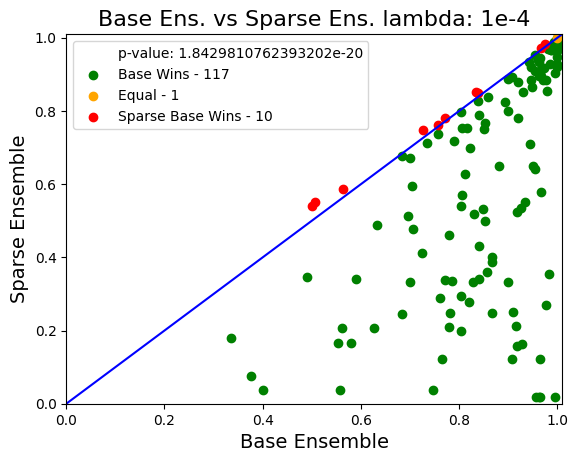

In [37]:
from scipy.stats import wilcoxon

# Perform the Wilcoxon signed-rank test
stat, p_value = wilcoxon(res_df_2['base_ens'].tolist(), res_df_2['sparse_ens'])
print('p_value: ', p_value)

plot_1v1_perf(res_df_2, 
              p_value, 
              x_y_lim=0.0, 
              acc_base=1.01, 
              co_col='sparse_ens', 
              base_col='base_ens', 
              xlabel='Base Ensemble', 
              ylabel='Sparse Ensemble', 
              legend_base='Base', 
              legend_co='Sparse Base', 
              title='Base Ens. vs Sparse Ens. lambda: 1e-4', 
              file_name=None)